In [1]:
%%capture
%load_ext autoreload
%autoreload 2
%reset -f
# %pip install matplotlib

In [2]:
import jax
import optax
from jax import numpy as jnp
from matplotlib import pyplot as plt

import sys
import os

# Add the parent folder (OTF) to sys.path
project_root = os.path.abspath(os.path.join("..", "..", "src"))
sys.path.append(project_root)

import otf
from otf import optim
from otf import time_integration as ti
from otf.asyncd import utils
from otf.system import System_ModelKnown

from plot import plot

jax.config.update("jax_platform_name", "cpu")
jax.config.update("jax_enable_x64", True)

jndarray = jnp.ndarray

In [3]:
def get_initial_values():
    # Initial true state near the unstable spiral (1, 3/2)
    u0 = jnp.array([1, 3/2], dtype=float)

    # Initial assimilated / nudged state
    # un0 = jnp.zeros_like(u0)
    un0 = u0

    return u0, un0


/Users/ashtynwhipple/Research Work/otf/examples/Lotka–Volterra/plot.py:41: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.set_yscale("log")


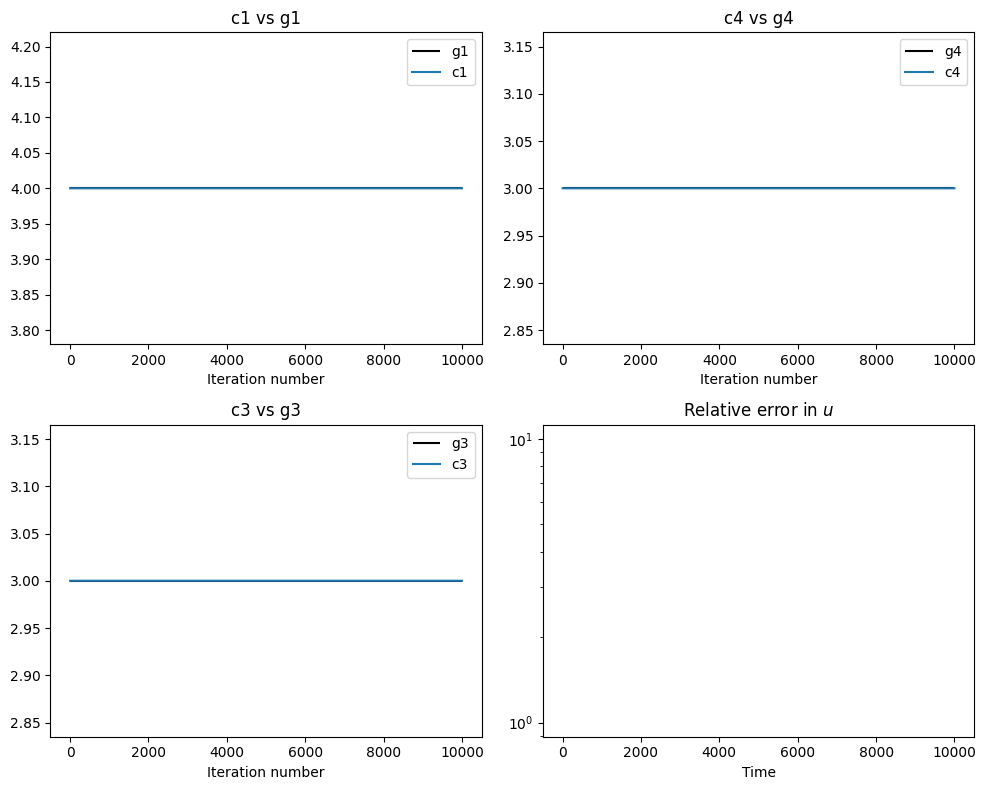

In [4]:
def true_ode(gs: jndarray, true: jndarray) -> jndarray:
    a, b, c, d = gs

    x, y = true

    dx = x - (x**2) / a - (x * y) / (1 + x)
    dy = -c * y + d * x * y / (1 + x)

    return jnp.array([dx, dy])


def assimilated_ode(cs: jndarray, nudged: jndarray) -> jndarray:
    a, b, c, d = cs

    x, y = nudged

    dx = x - (x**2) / a - (x * y) / (1 + x)
    dy = -c * y + d * x * y / (1 + x)

    return jnp.array([dx, dy])


# Nominal parameters (from the example)
a, b, c, d = 4.0, 1.0, 3.0, 3.0 
# cs = jnp.array([a, b, c, d])
g1, g2, g3, g4 = a, b, c, d
# Slightly mismatched parameters for assimilation
cs = jnp.array([
    a,
    b,
    c,
    d
])

gs = jnp.array([a, b, c, d])

mu = 20


# Initial conditions near the unstable spiral (1, 3/2)
# true0 = jnp.array([1.05, 1.55])
# assimilated0 = jnp.array([0.9, 1.4])

true0, assimilated0 = get_initial_values()

observed_slice = jnp.s_[:]
observed_mask = otf.system.utils.mask_from_slice(observed_slice, true0.shape)
system = System_ModelKnown(mu, gs, cs, observed_mask, assimilated_ode, true_ode)

solver = ti.ForwardEuler(system)
# solver = ti.RK4(system)
solver = ti.TwoStepAdamsBashforth(system, solver)
# optimizer = base_optim.LevenbergMarquardt(system, 1e-2)
optimizer = optax.adam(1e-1)
optimizer = optim.OptaxWrapper(system, optimizer)

# Simulation parameters
dt = 0.01
T0, Tf = 0, 10000
t_relax = 1

true_solver = solver
trues, tls_ = true_solver.solve_true(true0, T0, Tf, dt)

true_observed = trues[:, system.observed_mask]

cs, u_errors, tls, assimilateds = utils.run_update(
    system,
    true_observed,
    solver,
    dt,
    T0,
    Tf,
    t_relax,
    assimilated0,
    optimizer=optimizer,
    return_all=True,
)


fig, axs = plot(cs.T[0], cs.T[1], cs.T[2], cs.T[3], u_errors, g1, g2, g3, g4, tls)
plt.show()

In [5]:
# fig, axs = plot(cs.T[0], cs.T[1], cs.T[2], cs.T[3], u_errors, g1, g2, g3, g4, tls)
# plt.show()